<a href="https://colab.research.google.com/github/Chandrani45/MDTS4312_708/blob/main/kmeans%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPLEMENTING KMEANS FROM SCRATCH

In [135]:
import numpy as np

In [136]:
X = np.array([
    [1.0,1.0],
    [1.5,2.0],
    [3.0,4.0],
    [5.0,7.0],
    [3.5,5.0],
    [4.5,5.0],
    [3.5,4.5]
])

In [137]:
len(X)

7

In [138]:
centroid=np.array([1.0,1.0])

In [139]:
def compute(X,centroid,k):
  distances=[]
  for point in X:
    distance=np.sum((point-centroid)**2,axis=1)
    distance1=np.min(distance)
    distances.append(distance1)

  probability=np.array(distances)/np.sum(np.array(distances))
  max_prob=np.argmax(probability)
  return max_prob
k=3
centroids=[]
centroids.append(centroid)
for i in range(k-1):
 index=compute(X,np.array(centroids),k)
 new_centroid=X[index]
 centroids.append(new_centroid)
print(np.array(centroids))



[[1. 1.]
 [5. 7.]
 [3. 4.]]


In [140]:
def compute_distance(point,centroid):
  distance=np.linalg.norm(point-centroid,ord=2)
  return distance

In [141]:
def compute_closest_distance(point,centroids):
    distances=np.linalg.norm(centroids-point,ord=2,axis=1)
    idx=np.argmin(distances)
    return idx


In [142]:
def assign_clusters(X,centroids):
 idx=[]
 for point in X:
  cluster=compute_closest_distance(point,centroids)
  idx.append(cluster)
 return np.array(idx)

In [143]:
def compute_centroids(X,K,idx):
  new_centroids=[]
  for k in range(K):
    points=X[idx==k]
    centroids=np.mean(points,axis=0)
    new_centroids.append(centroids)
  return np.array(new_centroids)


In [144]:
def compute_cost(X,idx,centroids):
  m=len(X)
  total=0
  for i in range(m):
    centroid=centroids[idx[i]]
    total=total+np.sum((X[i]-centroid)**2)
  return total

In [145]:
def run_kmeans(X,centroids,max_iters=100):
  centroids=centroids.copy()
  for i in range(max_iters):
    idx=assign_clusters(X,centroids)
    new_centroids=compute_centroids(X,len(centroids),idx)
    if np.allclose(new_centroids,centroids):
      break
    centroids=new_centroids

  return centroids,idx

In [146]:
final_centroids,idx=run_kmeans(X,centroids)
final_centroids

array([[1.25 , 1.5  ],
       [5.   , 7.   ],
       [3.625, 4.625]])

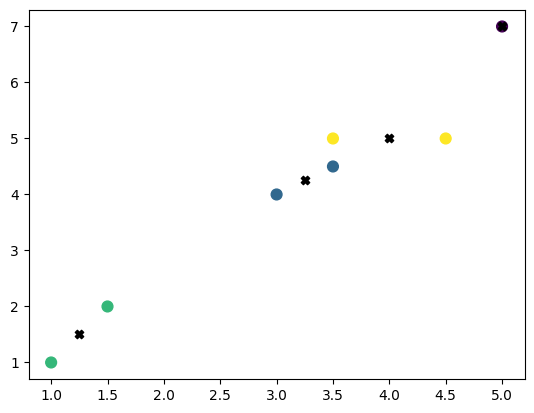

In [150]:
#plotting
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=idx,s=60)
plt.scatter(final_centroids[:,0],final_centroids[:,1],marker='X',color='black')


In [148]:
costs=[]
for k in range(2,5):
  indices=np.random.choice(len(X),k,replace=False)
  centroids=X[indices]
  final_centroids,idx=run_kmeans(X,centroids,max_iters=100)
  cost=compute_cost(X,idx,final_centroids)
  costs.append(cost)


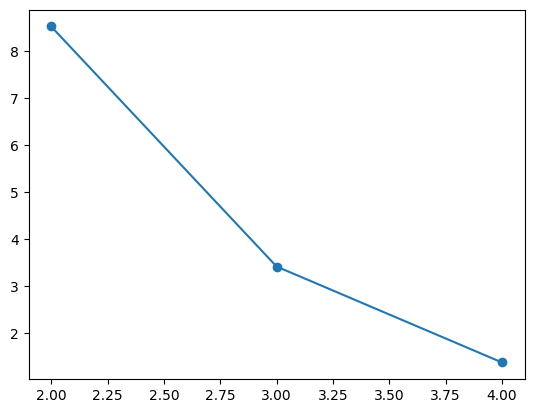

In [149]:
plt.plot(range(2,5),costs,marker='o')